<a href="https://colab.research.google.com/github/l22140141/Proyecto_unidad2/blob/main/ProyectoUnidad2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MARCH MACHINE LEARNING MANIA 2026 — STARTER KIT COMPLETO  
Kaggle Competition — NCAA Basketball                      

BASADO EN ANÁLISIS DE GANADORES HISTÓRICOS (2018-2025):
* @raddar solution (ganó múltiples ediciones): Team Quality via LRMC
* Top 2023 solution: XGBoost + Expanding Window CV + calibración     
* Top 2024/2025: Elo ratings + estadísticas avanzadas + ensemble     

ESTRUCTURA DEL PIPELINE:    
1.  Configuración y carga de datos                
2.  EDA — Análisis exploratorio          
3.  Sistema Elo (feature más importante histórica)    
4.  Feature engineering (seeds, stats, win rates, rankings)   
5.  Construcción de dataset de matchups           
6.  Modelos base (Logistic Regression, XGBoost, LightGBM)
7.  Stacking / Ensemble           
8.  Calibración de probabilidades (clave para Log Loss)    
9.  Validación temporal (Expanding Window CV)     
10. Generación de submission     

INSTRUCCIONES DE USO:

1. Descarga los datos de Kaggle y colócalos en DATA_DIR
2. Instala dependencias: pip install pandas numpy scikit-learn xgboost lightgbm matplotlib seaborn
3. Ejecuta sección por sección (o de corrido)
4. La submission final se guarda en SUBMISSION_PATH

MÉTRICA: Log Loss — se minimiza. Baseline (predict 0.5 siempre) ≈ 0.693
TARGET: < 0.55 para ser competitivo. Top 10% histórico: ~0.50


In [6]:
# ─── DEPENDENCIAS ─────────────────────────────────────────────────────────────
import os
import math
import warnings
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import cross_val_score
from sklearn.metrics import log_loss, brier_score_loss
from sklearn.pipeline import Pipeline

import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

In [7]:
# 0. CONFIGURACIÓN GLOBAL

# Directorios:
DATA_DIR        = Path("./sample_data")        # Carpeta con los CSV de Kaggle
OUTPUT_DIR      = Path("./outputs")
SUBMISSION_PATH = OUTPUT_DIR / "SubmissionStage1.csv"
FIGURES_DIR     = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

# Parámetros de la competencia
SEASON_2026     = 2026
GENDER          = "M"          # Cambiar a "W" para torneo femenino, o iterar ambos
CLIP_LOW        = 0.025        # Clipping de probabilidades (evitar log_loss = inf)
CLIP_HIGH       = 0.975
TRAIN_SINCE     = 2003         # Años desde los que entrenar
VAL_SEASONS     = [2022, 2023, 2024, 2025]  # Temporadas de validación

# Parámetros Elo (calibrados históricamente)
ELO_INIT        = 1500         # Rating inicial
ELO_K_FACTOR    = 20           # Factor de actualización base
ELO_WIDTH       = 400          # Escala de la función logística
ELO_MEAN_REV    = 0.6          # Regresión a la media entre temporadas (0=nada, 1=reset)
HFA             = 100          # Ventaja de local (Home Field Advantage)
SEED            = 42
np.random.seed(SEED)

# Paleta de colores para las gráficas
PALETTE = {"primary": "#1F4E79", "accent": "#C55A11", "success": "#375623",
           "light": "#D6E4F0", "gray": "#808080"}

print(f"   Datos en: {DATA_DIR.resolve()}")
print(f"   Salidas en: {OUTPUT_DIR.resolve()}")

   Datos en: /content/sample_data
   Salidas en: /content/outputs


In [8]:
# 1. CARGA DE DATOS

def load_data(gender: str = "M") -> dict:
    """
    Carga todos los archivos CSV de la competencia para el género indicado.
    gender = "M" (masculino) o "W" (femenino)
    """
    g = gender
    files = {
        "teams":             f"{g}Teams.csv",
        "seasons":           f"{g}Seasons.csv",
        "reg_compact":       f"{g}RegularSeasonCompactResults.csv",
        "reg_detailed":      f"{g}RegularSeasonDetailedResults.csv",
        "tourney_compact":   f"{g}NCAATourneyCompactResults.csv",
        "tourney_detailed":  f"{g}NCAATourneyDetailedResults.csv",
        "seeds":             f"{g}NCAATourneySeeds.csv",
        "slots":             f"{g}NCAATourneySlots.csv",
        "massey":            "MMasseyOrdinals.csv",   # Solo masculino
        "submission":        "SampleSubmissionStage1.csv",
    }

    data = {}
    for key, fname in files.items():
        path = DATA_DIR / fname
        if path.exists():
            data[key] = pd.read_csv(path)
            print(f"{fname:<50} {data[key].shape}")
        else:
            print(f"{fname} — NO ENCONTRADO (omitido)")

    return data

print("\n Datos cargados correctamente:")
data = load_data(GENDER)

# Alias convenientes
teams        = data.get("teams")
reg_compact  = data.get("reg_compact")
reg_detailed = data.get("reg_detailed")
seeds_df     = data.get("seeds")
tourney      = data.get("tourney_compact")
massey       = data.get("massey")
submission   = data.get("submission")





 Datos cargados correctamente:
MTeams.csv                                         (381, 4)
MSeasons.csv                                       (42, 6)
MRegularSeasonCompactResults.csv                   (196823, 8)
MRegularSeasonDetailedResults.csv                  (122775, 34)
MNCAATourneyCompactResults.csv                     (2585, 8)
MNCAATourneyDetailedResults.csv                    (1449, 34)
MNCAATourneySeeds.csv                              (2626, 3)
MNCAATourneySlots.csv                              (2586, 4)
MMasseyOrdinals.csv                                (1048575, 5)
SampleSubmissionStage1.csv                         (519144, 2)


In [9]:
# 2. EDA — ANÁLISIS EXPLORATORIO

def run_eda(reg_compact: pd.DataFrame, tourney: pd.DataFrame,
            seeds_df: pd.DataFrame)-> None:
    """Análisis exploratorio con visualizaciones clave."""
    print("\n EDA — Estadísticas generales")
    print(f"   Temporadas regulares: {reg_compact['Season'].min()} – {reg_compact['Season'].max()}")
    print(f"   Partidos regulares:   {len(reg_compact):,}")
    print(f"   Partidos de torneo:   {len(tourney):,}")

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("March Mania 2026 — EDA Overview", fontsize=16,
                 fontweight="bold", color=PALETTE["primary"])

    # Figura 1: Partidos por temporada
    ax = axes[0, 0]
    games_per_season = reg_compact.groupby("Season").size()
    ax.bar(games_per_season.index, games_per_season.values,
           color=PALETTE["primary"], alpha=0.8)
    ax.set_title("Partidos por Temporada (Regular)", fontweight="bold")
    ax.set_xlabel("Temporada"); ax.set_ylabel("# Partidos")
    ax.grid(axis="y", alpha=0.3)

    # Figura 2: Distribución de diferencias de puntaje
    ax = axes[0, 1]
    score_diff = reg_compact["WScore"] - reg_compact["LScore"]
    ax.hist(score_diff, bins=40, color=PALETTE["accent"], alpha=0.8, edgecolor="white")
    ax.axvline(score_diff.mean(), color="red", linestyle="--",
               label=f"Media: {score_diff.mean():.1f}")
    ax.set_title("Distribución Diferencia de Puntaje (Regular)", fontweight="bold")
    ax.set_xlabel("WScore - LScore"); ax.set_ylabel("Frecuencia")
    ax.legend(); ax.grid(alpha=0.3)

    # Figura 3: Índice de partidos ganados en torneo
    ax = axes[0, 2]
    if seeds_df is not None and tourney is not None:
      seeds_clean = seeds_df.copy()
      seeds_clean["SeedNum"] = seeds_clean["Seed"].str.extract(r"(\d+)").astype(int)
      t = tourney.merge(seeds_clean[["Season","TeamID","SeedNum"]], left_on=["Season","WTeamID"], right_on=["Season","TeamID"])
      t = t.rename(columns={"SeedNum": "WSeed"}).drop("TeamID", axis=1)
      t = t.merge(seeds_clean[["Season","TeamID","SeedNum"]], left_on=["Season","LTeamID"], right_on=["Season","TeamID"])
      t = t.rename(columns={"SeedNum": "LSeed"}).drop("TeamID", axis=1)

      seed_wins = t.groupby("WSeed").size().reset_index(name="Wins")
      seed_total = pd.concat([t[["WSeed"]].rename(columns={"WSeed":"Seed"}), t[["LSeed"]].rename(columns={"LSeed":"Seed"})]).groupby("Seed").size()
      seed_wr = (seed_wins.set_index("WSeed")["Wins"] / seed_total).reset_index()
      seed_wr.columns = ["Seed", "WinRate"]
      colors = [PALETTE["success"] if wr > 0.5 else PALETTE["accent"] for wr in seed_wr["WinRate"]]
      ax.bar(seed_wr["Seed"], seed_wr["WinRate"], color=colors, alpha=0.85)
      ax.axhline(0.5, color="gray", linestyle="--", alpha=0.7, label="50%")
      ax.set_title("Win Rate por Seed (Torneo)", fontweight="bold")
      ax.set_xlabel("Seed"); ax.set_ylabel("Win Rate")
      ax.legend(); ax.grid(alpha=0.3)

    # Figura 4: Victorias inesperadas por ronda
    ax = axes[1, 0]
    if seeds_df is not None and tourney is not None and "t" in dir():
        t["upset"] = t["WSeed"] > t["LSeed"]
        upset_by_season = t.groupby("Season")["upset"].mean()
        ax.plot(upset_by_season.index, upset_by_season.values,
                color=PALETTE["primary"], marker="o", markersize=4, linewidth=2)
        ax.fill_between(upset_by_season.index, upset_by_season.values,
                        alpha=0.15, color=PALETTE["primary"])
        ax.set_title("% de Upsets por Temporada (Torneo)", fontweight="bold")
        ax.set_xlabel("Temporada"); ax.set_ylabel("% Upsets")
        ax.grid(alpha=0.3)

    # Figura 5: Distribución puntajes ganadores vs perdedores
    ax = axes[1, 1]
    recent = reg_compact[reg_compact["Season"] >= 2015]
    ax.hist(recent["WScore"], bins=40, alpha=0.6, label="Ganador", color=PALETTE["success"])
    ax.hist(recent["LScore"], bins=40, alpha=0.6, label="Perdedor",color=PALETTE["accent"])
    ax.set_title("Distribución de Puntajes (desde 2015)", fontweight="bold")
    ax.set_xlabel("Puntaje"); ax.set_ylabel("Frecuencia")
    ax.legend(); ax.grid(alpha=0.3)

    # Figura 6: Distribución de puntajes en el torneo
    ax = axes[1, 2]
    if seeds_df is not None:
        seeds_clean2 = seeds_df.copy()
        seeds_clean2["SeedNum"] = seeds_clean2["Seed"].str.extract(r"(\d+)").astype(int)
        recent_seeds = seeds_clean2[seeds_clean2["Season"] >= 2015]
        seed_counts = recent_seeds["SeedNum"].value_counts().sort_index()
        ax.bar(seed_counts.index, seed_counts.values, color=PALETTE["light"], edgecolor=PALETTE["primary"], linewidth=0.8)
        ax.set_title("Distribución de Seeds en Torneo (desde 2015)", fontweight="bold")
        ax.set_xlabel("Seed"); ax.set_ylabel("# Equipos")
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "01_eda_overview.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("   ✓ Plot guardado: 01_eda_overview.png")


In [10]:
reg_compact.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1985,20,1228,81,1328,64,N,0
1,1985,25,1106,77,1354,70,H,0
2,1985,25,1112,63,1223,56,H,0
3,1985,25,1165,70,1432,54,H,0
4,1985,25,1192,86,1447,74,H,0


In [11]:
tourney.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1985,136,1116,63,1234,54,N,0
1,1985,136,1120,59,1345,58,N,0
2,1985,136,1207,68,1250,43,N,0
3,1985,136,1229,58,1425,55,N,0
4,1985,136,1242,49,1325,38,N,0


In [12]:
seeds_df.head()

,Season,Seed,TeamID
0,1985,W01,1207
1,1985,W02,1210
2,1985,W03,1228
3,1985,W04,1260
4,1985,W05,1374



 EDA — Estadísticas generales
   Temporadas regulares: 1985 – 2026
   Partidos regulares:   196,823
   Partidos de torneo:   2,585


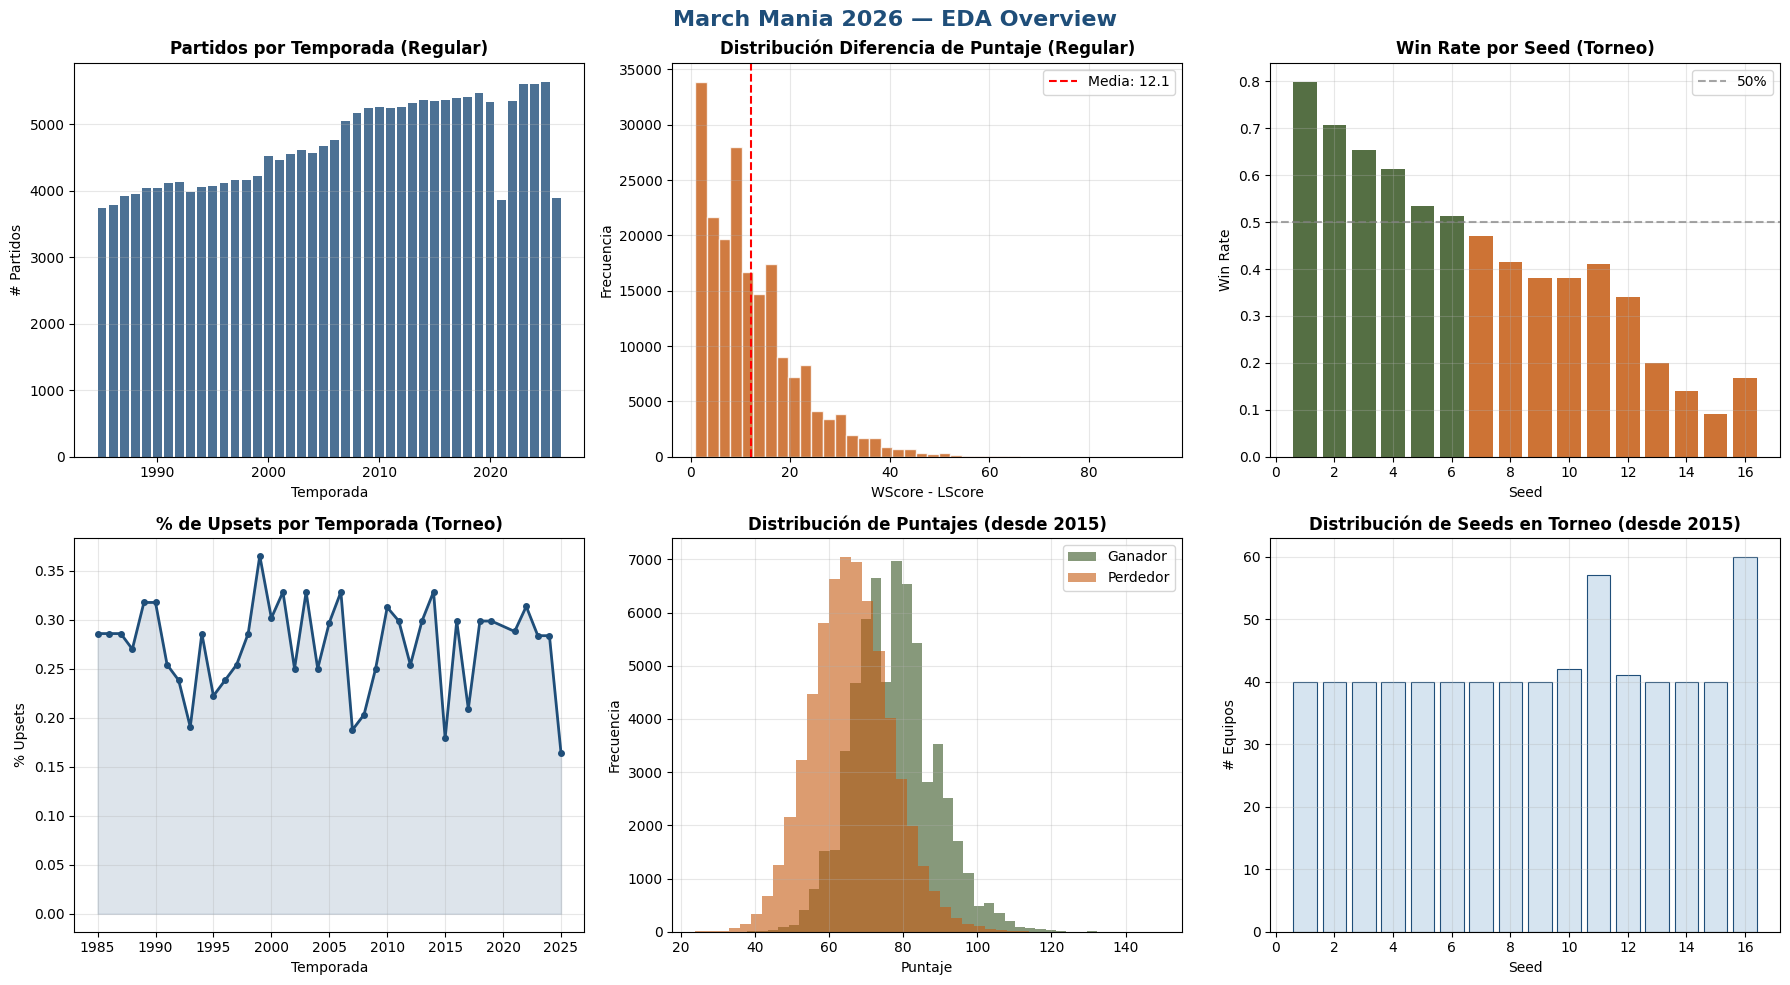

   ✓ Plot guardado: 01_eda_overview.png


In [13]:
run_eda(reg_compact, tourney, seeds_df)

In [14]:
# 3. SISTEMA ELO (Feature #1 de los ganadores históricos)
"""
INSIGHT DE GANADORES:
- La solución @raddar (ganó en 2018 y fue base de ganadores en 2022, 2023)
  usa un sistema de "Team Quality" calculado a partir de resultados de
  temporada regular con un proceso similar a Elo.
- Los Elo ratings capturan la fuerza relativa de un equipo acumulada a lo
  largo de toda su historia, ajustándose game a game.
- K-factor ajustado por margen de victoria es más predictivo que K fijo.
"""

def compute_elo_ratings(games: pd.DataFrame,
                        k_base: float = ELO_K_FACTOR,
                        elo_width: float = ELO_WIDTH,
                        init_elo: float = ELO_INIT,
                        mean_reversion: float = ELO_MEAN_REV,
                        hfa: float = HFA,
                        mov_adj: bool = True) -> dict:
    """
    Calcula Elo ratings para todos los equipos iterando por cada partido
    en orden cronológico.

    Parámetros:
        games          : DataFrame con columnas Season, DayNum, WTeamID, LTeamID,
                         WScore, LScore, WLoc
        k_base         : Factor K base de actualización
        elo_width      : Escala de la función logística (400 en ajedrez)
        init_elo       : Rating inicial de equipos nuevos
        mean_reversion : Regresión a la media al inicio de nueva temporada
        hfa            : Bonus de Elo por jugar en casa
        mov_adj        : Si ajustar K por margen de victoria (recomendado)

    Retorna:
        dict: {(season, daynum, teamid): elo_BEFORE_the_game}
        También accesible como snapshots_df
    """
    elos = {}            # team_id → elo actual
    history = []         # lista de snapshots

    games_sorted = games.sort_values(["Season", "DayNum"]).copy()
    prev_season = None

    for _, row in games_sorted.iterrows():
        season   = row["Season"]
        w_id     = row["WTeamID"]
        l_id     = row["LTeamID"]
        w_score  = row["WScore"]
        l_score  = row["LScore"]
        loc      = row.get("WLoc", "N")  # H=Home, A=Away, N=Neutral

        # Regresión a la media al inicio de nueva temporada
        if season != prev_season:
            for tid in elos:
                elos[tid] = init_elo * mean_reversion + elos[tid] * (1 - mean_reversion)
            prev_season = season

        # Inicializar equipos nuevos
        elos.setdefault(w_id, init_elo)
        elos.setdefault(l_id, init_elo)

        elo_w = elos[w_id]
        elo_l = elos[l_id]

        # Ajuste por local (WLoc desde perspectiva del ganador)
        if loc == "H":   # Ganador jugó en casa
            elo_w_adj = elo_w + hfa
        elif loc == "A": # Ganador jugó de visitante (fue upset de local)
            elo_w_adj = elo_w - hfa
        else:
            elo_w_adj = elo_w

        # Probabilidad esperada de victoria del ganador
        exp_w = 1.0 / (1.0 + 10 ** ((elo_l - elo_w_adj) / elo_width))

        # Factor K ajustado por margen de victoria (idea de FiveThirtyEight)
        margin = w_score - l_score
        if mov_adj:
            # Elo_winner_diff: diferencia de Elo para ponderar (equipos similares
            # merecen más K cuando el margen es grande)
            elo_diff = abs(elo_w - elo_l) + 1
            k_factor = k_base * math.log1p(margin) * (2.2 / (elo_diff * 0.001 + 2.2))
        else:
            k_factor = k_base

        # Snapshot ANTES de actualizar (para usar como feature del partido)
        history.append({
            "Season": season,
            "DayNum": row["DayNum"],
            "WTeamID": w_id,
            "LTeamID": l_id,
            "EloW_pre": elo_w,
            "EloL_pre": elo_l,
        })

        # Actualización Elo
        elos[w_id] = elo_w + k_factor * (1.0 - exp_w)
        elos[l_id] = elo_l + k_factor * (0.0 - (1 - exp_w))

    snapshots_df = pd.DataFrame(history)
    print(f"Elo calculado: {len(elos)} equipos únicos | {len(snapshots_df):,} partidos procesados")
    return elos, snapshots_df

print("\n Calculando sistema Elo...")
elo_final, elo_snapshots = compute_elo_ratings(reg_compact)

def get_season_end_elos(reg_compact: pd.DataFrame) -> pd.DataFrame:
    """
    Devuelve el Elo final de cada equipo AL FINAL de la temporada regular
    (justo antes del torneo) — el feature más importante.
    """
    elos = {}
    prev_season = None
    season_end_elos = []

    games_sorted = reg_compact.sort_values(["Season", "DayNum"])

    for season, grp in games_sorted.groupby("Season"):
        # Regresión a la media
        if prev_season is not None:
            for tid in elos:
                elos[tid] = ELO_INIT * ELO_MEAN_REV + elos[tid] * (1 - ELO_MEAN_REV)

        for _, row in grp.iterrows():
            w_id, l_id = row["WTeamID"], row["LTeamID"]
            w_sc, l_sc = row["WScore"], row["LScore"]
            loc = row.get("WLoc", "N")

            elos.setdefault(w_id, ELO_INIT)
            elos.setdefault(l_id, ELO_INIT)
            elo_w, elo_l = elos[w_id], elos[l_id]

            elo_w_adj = elo_w + (HFA if loc == "H" else (-HFA if loc == "A" else 0))
            exp_w = 1.0 / (1.0 + 10 ** ((elo_l - elo_w_adj) / ELO_WIDTH))
            margin = w_sc - l_sc
            elo_diff = abs(elo_w - elo_l) + 1
            k = ELO_K_FACTOR * math.log1p(margin) * (2.2 / (elo_diff * 0.001 + 2.2))

            elos[w_id] = elo_w + k * (1.0 - exp_w)
            elos[l_id] = elo_l + k * (0.0 - (1.0 - exp_w))

        # Snapshot al final de la temporada regular
        for tid, elo_val in elos.items():
            season_end_elos.append({"Season": season, "TeamID": tid, "EloRating": elo_val})

        prev_season = season

    return pd.DataFrame(season_end_elos)

print("Calculando Elo al final de cada temporada regular...")
elo_season_end = get_season_end_elos(reg_compact)
print(f"{len(elo_season_end):,} registros (Temporada × Equipo)")




 Calculando sistema Elo...
Elo calculado: 381 equipos únicos | 196,823 partidos procesados
Calculando Elo al final de cada temporada regular...
14,206 registros (Temporada × Equipo)


In [15]:
# 4. FEATURE ENGINEERING
"""
FEATURES USADAS POR LOS MEJORES MODELOS HISTÓRICOS:
  1. Diferencia de Elo (la más importante, históricamente)
  2. Diferencia de seed
  3. Win rate en temporada regular
  4. Diferencial de puntaje promedio
  5. Eficiencia ofensiva y defensiva (adjusted)
  6. Four Factors: eFG%, TOV%, ORB%, FT rate
  7. Rankings externos (Massey Ordinals — si disponibles)
  8. Historial H2H (head to head) en torneo

FORMATO DEL DATASET:
  Cada fila = un matchup Team1 vs Team2
  La variable target = 1 si Team1 (lower ID) gana, 0 si gana Team2
  Los features son DIFERENCIAS: feat_T1 - feat_T2
"""

def build_team_season_stats(reg_detailed: pd.DataFrame) -> pd.DataFrame:
    """
    Construye estadísticas promedio de cada equipo por temporada
    a partir del DataFrame de resultados detallados.

    Incluye estadísticas ofensivas y defensivas separadas.
    """
    if reg_detailed is None:
        print("   ⚠ reg_detailed no disponible, omitiendo stats detalladas")
        return None

    # Crear perspectiva del ganador
    w_stats = reg_detailed[[
        "Season", "WTeamID",
        "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA",
        "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF",
        "WScore",
        "LFGM", "LFGA", "LFGM3", "LFGA3",  # Oponente = defensa
        "LScore"
    ]].copy()
    w_stats.columns = [
        "Season", "TeamID",
        "FGM", "FGA", "FGM3", "FGA3", "FTM", "FTA",
        "OR", "DR", "Ast", "TO", "Stl", "Blk", "PF",
        "Pts_scored",
        "Opp_FGM", "Opp_FGA", "Opp_FGM3", "Opp_FGA3",
        "Pts_allowed"
    ]

    # Crear perspectiva del perdedor
    l_stats = reg_detailed[[
        "Season", "LTeamID",
        "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA",
        "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
        "LScore",
        "WFGM", "WFGA", "WFGM3", "WFGA3",
        "WScore"
    ]].copy()
    l_stats.columns = [
        "Season", "TeamID",
        "FGM", "FGA", "FGM3", "FGA3", "FTM", "FTA",
        "OR", "DR", "Ast", "TO", "Stl", "Blk", "PF",
        "Pts_scored",
        "Opp_FGM", "Opp_FGA", "Opp_FGM3", "Opp_FGA3",
        "Pts_allowed"
    ]

    all_stats = pd.concat([w_stats, l_stats], ignore_index=True)

    # Agregaciones por equipo / temporada
    agg = all_stats.groupby(["Season", "TeamID"]).agg(
        Games       = ("FGM", "count"),
        FGM         = ("FGM", "mean"),
        FGA         = ("FGA", "mean"),
        FGM3        = ("FGM3", "mean"),
        FGA3        = ("FGA3", "mean"),
        FTM         = ("FTM", "mean"),
        FTA         = ("FTA", "mean"),
        OR          = ("OR", "mean"),
        DR          = ("DR", "mean"),
        Ast         = ("Ast", "mean"),
        TO          = ("TO", "mean"),
        Stl         = ("Stl", "mean"),
        Blk         = ("Blk", "mean"),
        PF          = ("PF", "mean"),
        Pts_scored  = ("Pts_scored", "mean"),
        Pts_allowed = ("Pts_allowed", "mean"),
        Opp_FGM     = ("Opp_FGM", "mean"),
        Opp_FGA     = ("Opp_FGA", "mean"),
        Opp_FGM3    = ("Opp_FGM3", "mean"),
        Opp_FGA3    = ("Opp_FGA3", "mean"),
    ).reset_index()

    # Factores (Dean Oliver)
    # 1. Effective Field Goal % (eFG) — pondera triples
    agg["eFG_off"] = (agg["FGM"] + 0.5 * agg["FGM3"]) / agg["FGA"].replace(0, np.nan)
    agg["eFG_def"] = (agg["Opp_FGM"] + 0.5 * agg["Opp_FGM3"]) / agg["Opp_FGA"].replace(0, np.nan)

    # 2. Turnover % (TOV) — posesiones perdidas
    poss_est = agg["FGA"] + 0.44 * agg["FTA"] - agg["OR"] + agg["TO"]
    agg["TOV_pct"] = agg["TO"] / poss_est.replace(0, np.nan)

    # 3. Offensive Rebound % (ORB)
    agg["ORB_pct"] = agg["OR"] / (agg["OR"] + agg["DR"]).replace(0, np.nan)

    # 4. Free Throw Rate (FTR)
    agg["FTR"]     = agg["FTM"] / agg["FGA"].replace(0, np.nan)

    # Métricas adicionales
    agg["FG_pct"]      = agg["FGM"] / agg["FGA"].replace(0, np.nan)
    agg["FG3_pct"]     = agg["FGM3"] / agg["FGA3"].replace(0, np.nan)
    agg["FT_pct"]      = agg["FTM"] / agg["FTA"].replace(0, np.nan)
    agg["Ast_TO_ratio"] = agg["Ast"] / agg["TO"].replace(0, np.nan)
    agg["Pt_diff"]     = agg["Pts_scored"] - agg["Pts_allowed"]  # Margen promedio

    # True Shooting % (TS%)
    ts_denom = 2 * (agg["FGA"] + 0.44 * agg["FTA"])
    agg["TS_pct"] = agg["Pts_scored"] / ts_denom.replace(0, np.nan)

    print(f"Estadísticas calculadas: {agg.shape} (Season × Team × {agg.shape[1]-2} features)")
    return agg

def build_win_rates(reg_compact: pd.DataFrame) -> pd.DataFrame:
    """
    Calcula win rate, media y desviación del margen de victoria
    para cada equipo por temporada, usando resultados compactos.
    """
    w = reg_compact[["Season", "WTeamID", "WScore", "LScore"]].copy()
    w.columns = ["Season", "TeamID", "Score_for", "Score_against"]
    w["Win"] = 1

    l = reg_compact[["Season", "LTeamID", "LScore", "WScore"]].copy()
    l.columns = ["Season", "TeamID", "Score_for", "Score_against"]
    l["Win"] = 0

    all_games = pd.concat([w, l], ignore_index=True)
    all_games["Margin"] = all_games["Score_for"] - all_games["Score_against"]

    wr = all_games.groupby(["Season", "TeamID"]).agg(
        WinRate   = ("Win", "mean"),
        AvgMargin = ("Margin", "mean"),
        StdMargin = ("Margin", "std"),
        NumGames  = ("Win", "count"),
    ).reset_index()

    print(f"Índices de victorias calculadas: {wr.shape}")
    return wr

def get_seed_numeric(seeds_df: pd.DataFrame) -> pd.DataFrame:
    """Extrae el número de seed (1-16) desde la columna string 'W01a' → 1."""
    s = seeds_df.copy()
    s["SeedNum"] = s["Seed"].str.extract(r"(\d+)").astype(int)
    return s[["Season", "TeamID", "SeedNum"]]

def get_massey_features(massey: pd.DataFrame,
                        systems: list = ["RTH", "SAG", "POM", "WOL", "RPI"],
                        max_day: int = 133) -> pd.DataFrame:
    """
    Extrae rankings de Massey Ordinals para los sistemas más conocidos.
    Se usa el ranking más reciente ANTES del torneo (DayNum <= 133).
    Rango más bajo = equipo más fuerte.
    """
    if massey is None:
        return None

    m = massey[massey["RankingDayNum"] <= max_day].copy()
    m_latest = m.sort_values("RankingDayNum").groupby(
        ["Season", "SystemName", "TeamID"]
    ).last().reset_index()

    # Filtrar sistemas de interés
    available_sys = [s for s in systems if s in m_latest["SystemName"].unique()]
    if not available_sys:
        available_sys = m_latest["SystemName"].value_counts().head(3).index.tolist()
        print(f"   ⚠ Sistemas solicitados no encontrados. Usando: {available_sys}")

    m_filtered = m_latest[m_latest["SystemName"].isin(available_sys)]
    m_pivot = m_filtered.pivot_table(
        index=["Season", "TeamID"],
        columns="SystemName",
        values="OrdinalRank",
        aggfunc="last"
    ).reset_index()

    m_pivot.columns = ["Season", "TeamID"] + [f"Massey_{s}" for s in m_pivot.columns[2:]]
    m_pivot["Massey_avg"] = m_pivot.iloc[:, 2:].mean(axis=1)

    print(f"Características del rating Massey Ordinals: {m_pivot.shape} | Sistemas: {available_sys}")
    return m_pivot

print("\n Ingeniería de características:")
team_stats  = build_team_season_stats(reg_detailed)
win_rates   = build_win_rates(reg_compact)
seeds_clean = get_seed_numeric(seeds_df)
massey_feat = get_massey_features(massey) if massey is not None else None




 Ingeniería de características:
Estadísticas calculadas: (8346, 33) (Season × Team × 31 features)
Índices de victorias calculadas: (13753, 6)
Características del rating Massey Ordinals: (2688, 8) | Sistemas: ['RTH', 'SAG', 'POM', 'WOL', 'RPI']


In [16]:
# 5. CONSTRUCCIÓN DEL DATASET DE MATCHUPS

def build_matchup_dataset(tourney: pd.DataFrame,
                          elo_season_end: pd.DataFrame,
                          seeds_clean: pd.DataFrame,
                          win_rates: pd.DataFrame,
                          team_stats: pd.DataFrame = None,
                          massey_feat: pd.DataFrame = None) -> pd.DataFrame:
    """
    Construye el dataset de entrenamiento.
    Cada fila = un partido del torneo histórico.
    Features = diferencias entre Team1 y Team2 (Team1 = lower TeamID).
    Target = 1 si Team1 (lower ID) gana.
    """
    df = tourney.copy()

    # Ordenar equipos: Team1 siempre tiene menor ID (convención de Kaggle)
    df["Team1"] = df[["WTeamID", "LTeamID"]].min(axis=1)
    df["Team2"] = df[["WTeamID", "LTeamID"]].max(axis=1)
    df["Target"] = (df["WTeamID"] == df["Team1"]).astype(int)

    def merge_feature(df, feat_df, feat_cols, suffix1, suffix2, on=["Season", "TeamID"]):
        """Auxiliar para hacer merge de features para ambos equipos."""
        if feat_df is None:
            return df
        t1_cols = {c: f"{c}_{suffix1}" for c in feat_cols}
        t2_cols = {c: f"{c}_{suffix2}" for c in feat_cols}

        df = df.merge(
            feat_df[["Season", "TeamID"] + feat_cols].rename(columns={**{"TeamID": "Team1"}, **t1_cols}),
            on=["Season", "Team1"], how="left"
        )
        df = df.merge(
            feat_df[["Season", "TeamID"] + feat_cols].rename(columns={**{"TeamID": "Team2"}, **t2_cols}),
            on=["Season", "Team2"], how="left"
        )
        return df

    # ── Elo ──────────────────────────────────────────────────────────────────
    df = merge_feature(df, elo_season_end, ["EloRating"], "T1", "T2")
    df["EloRating_diff"] = df["EloRating_T1"] - df["EloRating_T2"]

    # ── Seeds ────────────────────────────────────────────────────────────────
    df = merge_feature(df, seeds_clean, ["SeedNum"], "T1", "T2")
    df["SeedNum_diff"] = df["SeedNum_T1"] - df["SeedNum_T2"]
    # Seed más bajo = equipo más fuerte → diff negativa favorece a Team1

    # ── Win rates ─────────────────────────────────────────────────────────────
    wr_cols = ["WinRate", "AvgMargin", "StdMargin"]
    df = merge_feature(df, win_rates, wr_cols, "T1", "T2")
    df["WinRate_diff"]   = df["WinRate_T1"]   - df["WinRate_T2"]
    df["AvgMargin_diff"] = df["AvgMargin_T1"] - df["AvgMargin_T2"]

    # ── Estadísticas detalladas ───────────────────────────────────────────────
    if team_stats is not None:
        stat_cols = [
            "eFG_off", "eFG_def", "TOV_pct", "ORB_pct", "FTR",
            "Pt_diff", "TS_pct", "FG3_pct", "Ast_TO_ratio"
        ]
        stat_cols = [c for c in stat_cols if c in team_stats.columns]
        df = merge_feature(df, team_stats, stat_cols, "T1", "T2")
        for c in stat_cols:
            df[f"{c}_diff"] = df[f"{c}_T1"] - df[f"{c}_T2"]

    # ── Massey Ordinals ───────────────────────────────────────────────────────
    if massey_feat is not None:
        m_cols = [c for c in massey_feat.columns if c.startswith("Massey")]
        df = merge_feature(df, massey_feat, m_cols, "T1", "T2")
        for c in m_cols:
            df[f"{c}_diff"] = df[f"{c}_T1"] - df[f"{c}_T2"]
        # Massey: rango menor = equipo mejor → diff negativa favorece a Team1

    # ── Espejo del dataset (muy importante) ──────────────────────────────────
    # Duplicar cada matchup con equipos intercambiados y target negado
    # Esto evita que el modelo aprenda que Team1 (lower ID) siempre gana
    df_mirror = df.copy()
    df_mirror["Team1"], df_mirror["Team2"] = df["Team2"].copy(), df["Team1"].copy()
    df_mirror["Target"] = 1 - df["Target"]

    # Invertir todas las columnas _diff
    diff_cols = [c for c in df.columns if c.endswith("_diff")]
    for c in diff_cols:
        df_mirror[c] = -df[c]

    # También intercambiar T1/T2 en features absolutas
    t1_feats = [c for c in df.columns if c.endswith("_T1")]
    t2_feats = [c for c in df.columns if c.endswith("_T2")]
    for t1c, t2c in zip(t1_feats, t2_feats):
        df_mirror[t1c], df_mirror[t2c] = df[t2c].copy(), df[t1c].copy()

    df_full = pd.concat([df, df_mirror], ignore_index=True)

    print(f"Dataset construido: {df_full.shape}")
    print(f"Objetivo: {df_full['Target'].mean():.4f} (esperado ≈ 0.50 con espejo)")

    return df_full

print("\n Construyendo dataset de matchups...")
matchup_data = build_matchup_dataset(
    tourney, elo_season_end, seeds_clean, win_rates,
    team_stats, massey_feat
)

# ── Selección de features para el modelo ────────────────────────────────────
FEATURE_COLS = [c for c in matchup_data.columns if c.endswith("_diff")]
print(f"\n Caracterpustucas seleccionadas ({len(FEATURE_COLS)}):")
for i, f in enumerate(FEATURE_COLS, 1):
    print(f"   {i:2d}. {f}")



 Construyendo dataset de matchups...
Dataset construido: (5170, 70)
Objetivo: 0.5000 (esperado ≈ 0.50 con espejo)

 Caracterpustucas seleccionadas (19):
    1. EloRating_diff
    2. SeedNum_diff
    3. WinRate_diff
    4. AvgMargin_diff
    5. eFG_off_diff
    6. eFG_def_diff
    7. TOV_pct_diff
    8. ORB_pct_diff
    9. FTR_diff
   10. Pt_diff_diff
   11. TS_pct_diff
   12. FG3_pct_diff
   13. Ast_TO_ratio_diff
   14. Massey_POM_diff
   15. Massey_RPI_diff
   16. Massey_RTH_diff
   17. Massey_SAG_diff
   18. Massey_WOL_diff
   19. Massey_avg_diff


In [18]:
# 6. MODELOS BASE

def prepare_train_test(matchup_data: pd.DataFrame,
                       feature_cols: list,
                       val_season: int) -> tuple:
    """
    Prepara splits de entrenamiento y validación por temporada.
    Estrategia: train en temporadas < val_season, test en val_season.
    """
    train = matchup_data[
        (matchup_data["Season"] < val_season) &
        (matchup_data["Season"] >= TRAIN_SINCE)
    ]
    test = matchup_data[matchup_data["Season"] == val_season]

    X_train = train[feature_cols].fillna(0)
    y_train = train["Target"]
    X_test  = test[feature_cols].fillna(0)
    y_test  = test["Target"]

    return X_train, y_train, X_test, y_test

# Modelo 1: Logistic Regression (baseline sólido)
def build_logistic_model() -> Pipeline:
    """
    Regresión logística con normalización.
    Históricamente muy competitiva en esta competencia.
    """
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(C=0.1, max_iter=1000, random_state=SEED))
    ])

# Modelo 2: XGBoost (ganador en 2024, 2025)
def build_xgboost_model() -> xgb.XGBClassifier:
    """
    XGBoost tuneado para Log Loss.
    Los hiperparámetros aquí son un punto de partida — TUNEAR con Optuna.
    """
    return xgb.XGBClassifier(
        n_estimators      = 500,
        learning_rate     = 0.05,
        max_depth         = 4,
        min_child_weight  = 5,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        gamma             = 0.1,
        reg_alpha         = 0.1,
        reg_lambda        = 1.0,
        objective         = "binary:logistic",
        eval_metric       = "logloss",
        random_state      = SEED,
        verbosity         = 0,
        use_label_encoder = False,
        n_jobs            = -1
    )

# Modelo 3: LightGBM (alternativa rápida)
def build_lgbm_model() -> lgb.LGBMClassifier:
    """
    LightGBM — más rápido que XGBoost, resultados similares.
    """
    return lgb.LGBMClassifier(
        n_estimators    = 500,
        learning_rate   = 0.05,
        max_depth       = 4,
        num_leaves      = 15,
        min_child_samples = 20,
        subsample       = 0.8,
        colsample_bytree = 0.8,
        reg_alpha       = 0.1,
        reg_lambda      = 1.0,
        objective       = "binary",
        metric          = "binary_logloss",
        random_state    = SEED,
        verbose         = -1,
        n_jobs          = -1
    )

# ── Modelo 4: Stacking Ensemble ──────────────────────────────────────────────
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression as LR

def build_stacking_model(feature_cols: list) -> StackingClassifier:
    """
    Stacking: LR + XGB + LGBM → meta-learner LR.
    Ensemble simple pero efectivo históricamente.
    """
    base_estimators = [
        ("lr",   Pipeline([("scaler", StandardScaler()),
                           ("lr", LR(C=0.1, max_iter=1000, random_state=SEED))])),
        ("xgb",  build_xgboost_model()),
        ("lgbm", build_lgbm_model()),
    ]
    meta_learner = LR(C=1.0, max_iter=1000, random_state=SEED)
    return StackingClassifier(
        estimators           = base_estimators,
        final_estimator      = meta_learner,
        cv                   = 5,
        stack_method         = "predict_proba",
        passthrough          = False,
        n_jobs               = -1
    )



In [19]:
# 7. CALIBRACIÓN DE PROBABILIDADES (crítico para Log Loss)
"""
INSIGHT CRÍTICO DE GANADORES:
- Predecir probabilidades extremas (0.01 o 0.99) para upsets posibles
  destruye el Log Loss si el resultado es contrario.
- Los mejores modelos CALIBRAN sus probabilidades (Platt scaling o isotonic)
  y luego CLIPEAN al rango [0.025, 0.975].
- La calibración es especialmente importante en rondas 1 vs 16 (seed match).
"""

def calibrate_and_clip(model, X_cal: pd.DataFrame, y_cal: pd.Series,
                        method: str = "sigmoid") -> CalibratedClassifierCV:
    """
    Calibra un modelo ya entrenado usando Platt scaling (sigmoid) o
    isotonic regression, luego aplica clipping.
    """
    cal_model = CalibratedClassifierCV(model, method=method, cv="prefit")
    cal_model.fit(X_cal, y_cal)
    return cal_model

def safe_predict_proba(model, X: pd.DataFrame,
                       clip_low: float = CLIP_LOW,
                       clip_high: float = CLIP_HIGH) -> np.ndarray:
    """Predice probabilidades con clipping para evitar log_loss = inf."""
    probs = model.predict_proba(X)[:, 1]
    return np.clip(probs, clip_low, clip_high)



 Temporadas de validación: [2022, 2023, 2024, 2025]
----------------------------------------------------------------------

   Validando 2022 | Train: 2,362 | Test: 134
      LogisticReg    LogLoss: 0.6859 (raw: 0.6716)
      XGBoost        LogLoss: 0.9817 (raw: 0.7203)
      LightGBM       LogLoss: 1.0625 (raw: 0.7576)

   Validando 2023 | Train: 2,496 | Test: 134
      LogisticReg    LogLoss: 0.5895 (raw: 0.5873)
      XGBoost        LogLoss: 0.7655 (raw: 0.6167)
      LightGBM       LogLoss: 0.8314 (raw: 0.6420)

   Validando 2024 | Train: 2,630 | Test: 134
      LogisticReg    LogLoss: 0.5748 (raw: 0.5714)
      XGBoost        LogLoss: 0.6884 (raw: 0.5288)
      LightGBM       LogLoss: 0.8413 (raw: 0.5701)

   Validando 2025 | Train: 2,764 | Test: 134
      LogisticReg    LogLoss: 0.4778 (raw: 0.4799)
      XGBoost        LogLoss: 0.5267 (raw: 0.4853)
      LightGBM       LogLoss: 0.5089 (raw: 0.4875)

 RESUMEN TEMPORAL CV:
             Mean LogLoss    Std  Min LogLoss
Model      

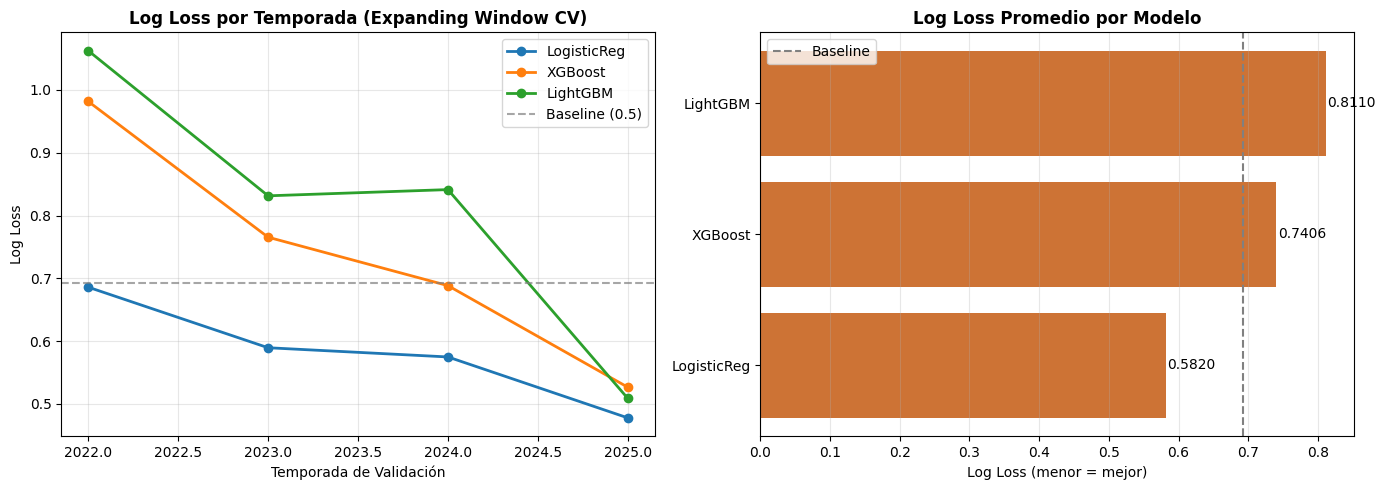

Figura guardada: 02_cv_results.png


In [20]:
# 8. VALIDACIÓN TEMPORAL (Expanding Window CV)
"""
ESTRATEGIA DE VALIDACIÓN:
La validación temporal (Expanding Window) es crucial aquí porque:
  1. El contexto deportivo cambia año a año (equipos, reglas, estilos)
  2. No hay filtración de datos del futuro al pasado
  3. Simula exactamente cómo se usa el modelo en producción

Expanding Window: train en [2003..2021], val en 2022
                  train en [2003..2022], val en 2023
                  train en [2003..2023], val en 2024
                  etc.
"""

def temporal_cv(matchup_data: pd.DataFrame,
                feature_cols: list,
                val_seasons: list = VAL_SEASONS) -> pd.DataFrame:
    """
    Expanding Window Cross-Validation.
    Evalúa múltiples modelos por cada temporada de validación.
    """
    results = []

    print(f"\n Temporadas de validación: {val_seasons}")
    print("-" * 70)

    models = {
        "LogisticReg": build_logistic_model(),
        "XGBoost":     build_xgboost_model(),
        "LightGBM":    build_lgbm_model(),
    }

    for season in val_seasons:
        X_train, y_train, X_test, y_test = prepare_train_test(
            matchup_data, feature_cols, season
        )

        if len(X_test) == 0:
            print(f"   ⚠ No hay datos de torneo para {season}, saltando...")
            continue

        print(f"\n   Validando {season} | Train: {len(X_train):,} | Test: {len(X_test):,}")

        for name, model in models.items():
            try:
                model_fresh = (
                    build_logistic_model() if name == "LogisticReg" else
                    build_xgboost_model() if name == "XGBoost" else
                    build_lgbm_model()
                )
                model_fresh.fit(X_train.fillna(0), y_train)

                # Calibración con split del 20% del training
                cal_size = max(100, int(len(X_train) * 0.2))
                X_cal = X_train.iloc[-cal_size:]
                y_cal = y_train.iloc[-cal_size:]

                probs_raw = model_fresh.predict_proba(X_test.fillna(0))[:, 1]
                probs_cal = safe_predict_proba(
                    calibrate_and_clip(model_fresh, X_cal, y_cal), X_test.fillna(0)
                )

                ll_raw = log_loss(y_test, np.clip(probs_raw, CLIP_LOW, CLIP_HIGH))
                ll_cal = log_loss(y_test, probs_cal)

                results.append({
                    "Season":    season,
                    "Model":     name,
                    "LogLoss":   ll_cal,
                    "LogLoss_raw": ll_raw,
                    "N_games":   len(X_test),
                })
                print(f"      {name:<14} LogLoss: {ll_cal:.4f} (raw: {ll_raw:.4f})")

            except Exception as e:
                print(f"      {name:<14} ERROR: {e}")

    results_df = pd.DataFrame(results)

    # Resumen
    if len(results_df) > 0:
        print("\n RESUMEN TEMPORAL CV:")
        summary = results_df.groupby("Model")["LogLoss"].agg(["mean", "std", "min"])
        summary.columns = ["Mean LogLoss", "Std", "Min LogLoss"]
        print(summary.sort_values("Mean LogLoss").to_string())
        print(f"\n Datos iniciales (predict 0.5): 0.6931")

    return results_df

cv_results = temporal_cv(matchup_data, FEATURE_COLS)

# Visualización de resultados CV
if len(cv_results) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    for model_name in cv_results["Model"].unique():
        model_res = cv_results[cv_results["Model"] == model_name]
        ax.plot(model_res["Season"], model_res["LogLoss"],
                marker="o", linewidth=2, markersize=6, label=model_name)
    ax.axhline(0.6931, color="gray", linestyle="--", alpha=0.7, label="Baseline (0.5)")
    ax.set_title("Log Loss por Temporada (Expanding Window CV)", fontweight="bold")
    ax.set_xlabel("Temporada de Validación"); ax.set_ylabel("Log Loss")
    ax.legend(); ax.grid(alpha=0.3)

    ax2 = axes[1]
    model_means = cv_results.groupby("Model")["LogLoss"].mean().sort_values()
    colors = [PALETTE["success"] if v < 0.55 else PALETTE["accent"]
              for v in model_means.values]
    bars = ax2.barh(model_means.index, model_means.values, color=colors, alpha=0.85)
    ax2.axvline(0.6931, color="gray", linestyle="--", label="Baseline")
    for bar, val in zip(bars, model_means.values):
        ax2.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va="center", fontsize=10)
    ax2.set_title("Log Loss Promedio por Modelo", fontweight="bold")
    ax2.set_xlabel("Log Loss (menor = mejor)")
    ax2.legend(); ax2.grid(alpha=0.3, axis="x")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "02_cv_results.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figura guardada: 02_cv_results.png")




 Entrenando modelo final y generando entregas para 2026...
Modelo entrenado con 2,898 muestras
Reporte: 519,144 matchups para predecir

 Submission guardada: outputs/SubmissionStage1.csv
      Dimensiones: (519144, 2)
      PRedicciones:
        Media:   0.4625
        Mediana: 0.4448
        Min:     0.0250
        Max:     0.9750
        >0.7:    68446 matchups
        <0.3:    80918 matchups


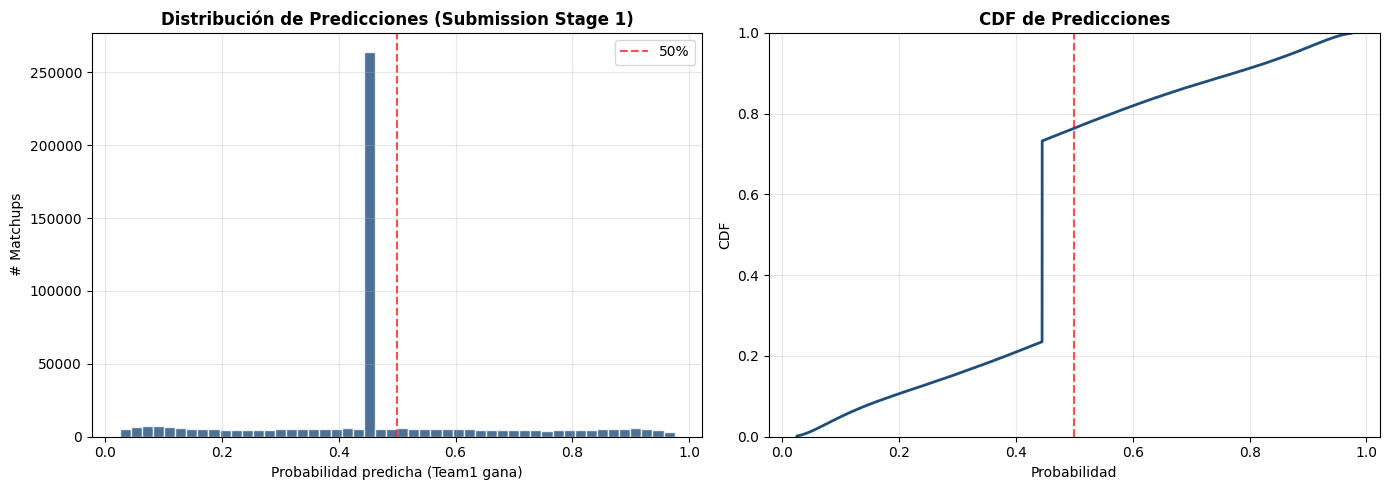

   ✓ Plot guardado: 03_submission_dist.png


In [21]:
# 9. ENTRENAMIENTO FINAL Y GENERACIÓN DE SUBMISSION

def generate_submission(submission_template: pd.DataFrame,
                        matchup_data: pd.DataFrame,
                        feature_cols: list,
                        elo_season_end: pd.DataFrame,
                        seeds_clean: pd.DataFrame,
                        win_rates: pd.DataFrame,
                        team_stats: pd.DataFrame = None,
                        massey_feat: pd.DataFrame = None,
                        target_season: int = SEASON_2026) -> pd.DataFrame:
    """
    Entrena el modelo final con todos los datos históricos y genera
    las predicciones para la submission de Stage 1.

    La submission contiene una probabilidad para CADA posible matchup
    del torneo 2026, no solo los que realmente ocurran.
    """
    print(f"\n Entrenando modelo final y generando entregas para {target_season}...")

    # ── Entrenamiento final en TODOS los datos históricos ──────────────────
    train_data = matchup_data[
        (matchup_data["Season"] >= TRAIN_SINCE)
    ]
    X_full = train_data[feature_cols].fillna(0)
    y_full = train_data["Target"]

    # Usar el mejor modelo según CV (XGBoost generalmente)
    final_model = build_xgboost_model()
    final_model.fit(X_full, y_full)
    print(f"Modelo entrenado con {len(X_full):,} muestras")

    # ── Parsear IDs de la submission ────────────────────────────────────────
    sub = submission_template.copy()
    sub["Season"] = sub["ID"].str.split("_").str[0].astype(int)
    sub["Team1"]  = sub["ID"].str.split("_").str[1].astype(int)
    sub["Team2"]  = sub["ID"].str.split("_").str[2].astype(int)

    print(f"Reporte: {len(sub):,} matchups para predecir")

    # ── Construir features para los matchups de submission ──────────────────
    def attach_features_sub(sub_df, feat_df, feat_cols, join_col="Team1", suffix="T1"):
        if feat_df is None:
            return sub_df
        renamed = feat_df[["Season", "TeamID"] + feat_cols].rename(
            columns={"TeamID": join_col, **{c: f"{c}_{suffix}" for c in feat_cols}}
        )
        return sub_df.merge(renamed, on=["Season", join_col], how="left")

    # Elo
    sub = attach_features_sub(sub, elo_season_end, ["EloRating"], "Team1", "T1")
    sub = attach_features_sub(sub, elo_season_end, ["EloRating"], "Team2", "T2")
    sub["EloRating_diff"] = sub["EloRating_T1"] - sub["EloRating_T2"]

    # Seeds
    sub = attach_features_sub(sub, seeds_clean, ["SeedNum"], "Team1", "T1")
    sub = attach_features_sub(sub, seeds_clean, ["SeedNum"], "Team2", "T2")
    sub["SeedNum_diff"] = sub["SeedNum_T1"] - sub["SeedNum_T2"]

    # Win rates
    wr_cols = ["WinRate", "AvgMargin", "StdMargin"]
    sub = attach_features_sub(sub, win_rates, wr_cols, "Team1", "T1")
    sub = attach_features_sub(sub, win_rates, wr_cols, "Team2", "T2")
    sub["WinRate_diff"]   = sub["WinRate_T1"]   - sub["WinRate_T2"]
    sub["AvgMargin_diff"] = sub["AvgMargin_T1"] - sub["AvgMargin_T2"]

    # Stats detalladas
    if team_stats is not None:
        stat_cols = [c for c in [
            "eFG_off", "eFG_def", "TOV_pct", "ORB_pct", "FTR",
            "Pt_diff", "TS_pct", "FG3_pct", "Ast_TO_ratio"
        ] if c in team_stats.columns]
        sub = attach_features_sub(sub, team_stats, stat_cols, "Team1", "T1")
        sub = attach_features_sub(sub, team_stats, stat_cols, "Team2", "T2")
        for c in stat_cols:
            sub[f"{c}_diff"] = sub[f"{c}_T1"] - sub[f"{c}_T2"]

    # Massey
    if massey_feat is not None:
        m_cols = [c for c in massey_feat.columns if c.startswith("Massey")]
        sub = attach_features_sub(sub, massey_feat, m_cols, "Team1", "T1")
        sub = attach_features_sub(sub, massey_feat, m_cols, "Team2", "T2")
        for c in m_cols:
            sub[f"{c}_diff"] = sub[f"{c}_T1"] - sub[f"{c}_T2"]

    # Predicciones con clipping
    X_sub = sub[feature_cols].fillna(0)
    probs = np.clip(
        final_model.predict_proba(X_sub)[:, 1],
        CLIP_LOW, CLIP_HIGH
    )
    sub["Pred"] = probs

    # Ajuste especial: seed 1 vs 16 (históricamente nunca gana el 16)
    # Seeds solo disponibles si los datos de 2026 ya se publicaron
    if "SeedNum_T1" in sub.columns and "SeedNum_T2" in sub.columns:
        extreme_mismatch = (
            ((sub["SeedNum_T1"] <= 3) & (sub["SeedNum_T2"] >= 14)) |
            ((sub["SeedNum_T1"] >= 14) & (sub["SeedNum_T2"] <= 3))
        )
        # Para matchups muy disparejos, ajustamos hacia el favorito
        # pero sin llegar a extremos (ver nota de calibración)
        sub.loc[extreme_mismatch & (sub["SeedNum_T1"] < sub["SeedNum_T2"]),
                "Pred"] = sub.loc[
                    extreme_mismatch & (sub["SeedNum_T1"] < sub["SeedNum_T2"]),
                    "Pred"
                ].clip(lower=0.75)
        sub.loc[extreme_mismatch & (sub["SeedNum_T1"] > sub["SeedNum_T2"]),
                "Pred"] = sub.loc[
                    extreme_mismatch & (sub["SeedNum_T1"] > sub["SeedNum_T2"]),
                    "Pred"
                ].clip(upper=0.25)

    # Submission final
    final_sub = sub[["ID", "Pred"]].copy()
    final_sub.to_csv(SUBMISSION_PATH, index=False)

    print(f"\n Submission guardada: {SUBMISSION_PATH}")
    print(f"      Dimensiones: {final_sub.shape}")
    print(f"      PRedicciones:")
    print(f"        Media:   {final_sub['Pred'].mean():.4f}")
    print(f"        Mediana: {final_sub['Pred'].median():.4f}")
    print(f"        Min:     {final_sub['Pred'].min():.4f}")
    print(f"        Max:     {final_sub['Pred'].max():.4f}")
    print(f"        >0.7:    {(final_sub['Pred'] > 0.7).sum()} matchups")
    print(f"        <0.3:    {(final_sub['Pred'] < 0.3).sum()} matchups")

    return final_sub

# ── Ejecutar si la submission template existe ─────────────────────────────
if submission is not None:
    final_submission = generate_submission(
        submission, matchup_data, FEATURE_COLS,
        elo_season_end, seeds_clean, win_rates,
        team_stats, massey_feat
    )

    # ── Visualización de la distribución de predicciones ────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.hist(final_submission["Pred"], bins=50, color=PALETTE["primary"],
            alpha=0.8, edgecolor="white")
    ax.axvline(0.5, color="red", linestyle="--", label="50%", alpha=0.7)
    ax.set_title("Distribución de Predicciones (Submission Stage 1)", fontweight="bold")
    ax.set_xlabel("Probabilidad predicha (Team1 gana)")
    ax.set_ylabel("# Matchups"); ax.legend(); ax.grid(alpha=0.3)

    ax2 = axes[1]
    ax2.ecdf(final_submission["Pred"], color=PALETTE["primary"], linewidth=2)
    ax2.axvline(0.5, color="red", linestyle="--", alpha=0.7)
    ax2.set_title("CDF de Predicciones", fontweight="bold")
    ax2.set_xlabel("Probabilidad"); ax2.set_ylabel("CDF")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "03_submission_dist.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("   ✓ Plot guardado: 03_submission_dist.png")

else:
    print("\n⚠ submission template no encontrada — omitiendo generación de submission")
    print("   Asegúrate de que SampleSubmissionStage1.csv esté en DATA_DIR")




 Analizando importancia de features...


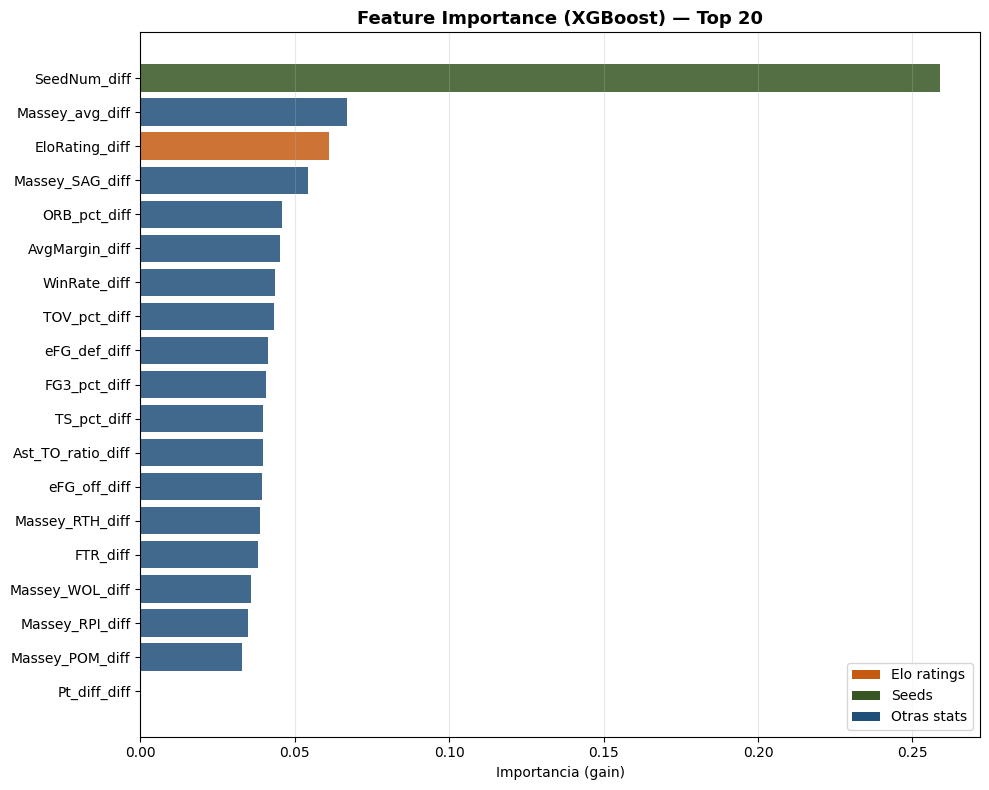

Plot guardado: 04_feature_importance.png


In [22]:

# 10. ANÁLISIS DE IMPORTANCIA DE FEATURES

def plot_feature_importance(feature_cols: list,
                            matchup_data: pd.DataFrame) -> None:
    """Entrena un XGBoost rápido y visualiza la importancia de features."""
    train_data = matchup_data[matchup_data["Season"] >= TRAIN_SINCE]
    X = train_data[feature_cols].fillna(0)
    y = train_data["Target"]

    model = xgb.XGBClassifier(n_estimators=200, max_depth=4,
                               random_state=SEED, verbosity=0,
                               use_label_encoder=False)
    model.fit(X, y)

    importance = pd.Series(model.feature_importances_, index=feature_cols)
    importance = importance.sort_values(ascending=True).tail(20)

    fig, ax = plt.subplots(figsize=(10, 8))
    colors = [PALETTE["accent"] if "Elo" in f else
              PALETTE["success"] if "Seed" in f else
              PALETTE["primary"] for f in importance.index]
    ax.barh(importance.index, importance.values, color=colors, alpha=0.85)
    ax.set_title("Feature Importance (XGBoost) — Top 20", fontweight="bold", fontsize=13)
    ax.set_xlabel("Importancia (gain)"); ax.grid(alpha=0.3, axis="x")

    # Leyenda de colores
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=PALETTE["accent"],  label="Elo ratings"),
        Patch(facecolor=PALETTE["success"], label="Seeds"),
        Patch(facecolor=PALETTE["primary"], label="Otras stats"),
    ]
    ax.legend(handles=legend_elements, loc="lower right")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "04_feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Plot guardado: 04_feature_importance.png")

print("\n Analizando importancia de features...")
if len(FEATURE_COLS) > 0:
    plot_feature_importance(FEATURE_COLS, matchup_data)



In [23]:
# 11. ROADMAP DE MEJORAS PARA COMPETIR EN TOP 10%

print("""
╔═══════════════════════════════════════════════════════════════════════════╗
║                    ROADMAP DE MEJORAS (Top 10% = ~0.50 LogLoss)           ║
╠═══════════════════════════════════════════════════════════════════════════╣
║                                                                           ║
║  PRIORIDAD ALTA (mayor impacto histórico):                                ║
║  ┣── 1. Tuning de hiperparámetros Elo (K, width, HFA, mean_reversion)     ║
║  ┣── 2. Integrar KenPom / BartTorvik metrics (AdjOE, AdjDE, Tempo)        ║
║  ┣── 3. Optuna hyperparameter tuning para XGBoost/LightGBM                ║
║  ┗── 4. Ensemble ponderado (cv-weighted average de modelos)               ║
║                                                                           ║
║  PRIORIDAD MEDIA:                                                         ║
║  ┣── 5. Features de momentum (últimos N partidos de temporada)            ║
║  ┣── 6. Head-to-head histórico entre equipos en torneos previos           ║
║  ┣── 7. Historial de upset rate por ronda (1vs16, 2vs15, etc.)            ║
║  ┗── 8. Eficiencia ajustada por calendario / fuerza del rival             ║
║                                                                           ║
║  PRIORIDAD BAJA (investigar):                                             ║
║  ┣── 9. Modelos de Deep Learning (LSTM para series de partidos)           ║
║  ┣── 10. Integrar datos de jugadores (transferencias, lesiones)           ║
║  ┗── 11. Torneo femenino: repetir pipeline con prefijo W                  ║
║                                                                           ║
║  ERRORES COMUNES A EVITAR:                                                ║
║  ┣── NO usar datos del torneo para entrenar features del torneo (leakage) ║
║  ┣── NO predecir 0 o 1 — siempre clipear a [0.025, 0.975]                 ║
║  ┣── NO ignorar la calibración de probabilidades                          ║
║  ┗── NO validar con train/test random split (usar solo temporal split)    ║
║                                                                           ║
╚═══════════════════════════════════════════════════════════════════════════╝
""")

print("Pipeline completo ejecutado exitosamente")
print(f"   Submission en: {SUBMISSION_PATH}")
print(f"   Figuras en:    {FIGURES_DIR}")


╔═══════════════════════════════════════════════════════════════════════════╗
║                    ROADMAP DE MEJORAS (Top 10% = ~0.50 LogLoss)           ║
╠═══════════════════════════════════════════════════════════════════════════╣
║                                                                           ║
║  PRIORIDAD ALTA (mayor impacto histórico):                                ║
║  ┣── 1. Tuning de hiperparámetros Elo (K, width, HFA, mean_reversion)     ║
║  ┣── 2. Integrar KenPom / BartTorvik metrics (AdjOE, AdjDE, Tempo)        ║
║  ┣── 3. Optuna hyperparameter tuning para XGBoost/LightGBM                ║
║  ┗── 4. Ensemble ponderado (cv-weighted average de modelos)               ║
║                                                                           ║
║  PRIORIDAD MEDIA:                                                         ║
║  ┣── 5. Features de momentum (últimos N partidos de temporada)            ║
║  ┣── 6. Head-to-head histórico entre equipos en torneos previ